##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [9]:
import os
import cv2
import math
import random
import zipfile
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model


In [10]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)


In [12]:
import os

dataset_directory = "action_youtube_naudio"

if os.path.isdir(dataset_directory):
    print("Dataset found:", dataset_directory)
else:
    print("Dataset NOT found. Check folder name or location.")

Dataset found: action_youtube_naudio


In [14]:
image_height, image_width = 64, 64
max_images_per_class = 1500

# The final labels we want to train on.
classes_list = ["diving", "walking", "horse_riding"]
model_output_size = len(classes_list)

print("Selected classes:", classes_list)
print("Number of output classes:", model_output_size)

Selected classes: ['diving', 'walking', 'horse_riding']
Number of output classes: 3


In [16]:
def normalize_name(name):
    return name.lower().replace(" ", "").replace("_", "").replace("-", "")

class_name_aliases = {
    "diving": ["diving"],
    "walking": ["walking"],
    "horse_riding": ["horse_riding", "horseriding"],
}

def find_class_folder(dataset_dir, class_name):
    if dataset_dir is None:
        raise ValueError("Dataset directory is not set. Please upload/extract the UCF11 dataset first.")

    available_folders = []
    video_extensions = (".avi", ".mp4", ".mpg", ".mpeg", ".mov")

    for root, dirs, files in os.walk(dataset_dir):
        has_video = any(file.lower().endswith(video_extensions) for file in files)
        if has_video:
            available_folders.append(root)

    aliases = [normalize_name(x) for x in class_name_aliases[class_name]]

    for folder in available_folders:
        folder_base = normalize_name(os.path.basename(folder))
        if folder_base in aliases:
            return folder

    for folder in available_folders:
        folder_norm = normalize_name(folder)
        if any(alias in folder_norm for alias in aliases):
            return folder

    raise FileNotFoundError(f"Could not find folder for class: {class_name}")

class_folder_paths = {}

for class_name in classes_list:
    class_folder_paths[class_name] = find_class_folder(dataset_directory, class_name)
    print(class_name, "->", class_folder_paths[class_name])

diving -> action_youtube_naudio/diving/v_diving_11
walking -> action_youtube_naudio/walking/v_walk_dog_05
horse_riding -> action_youtube_naudio/horse_riding/v_riding_09


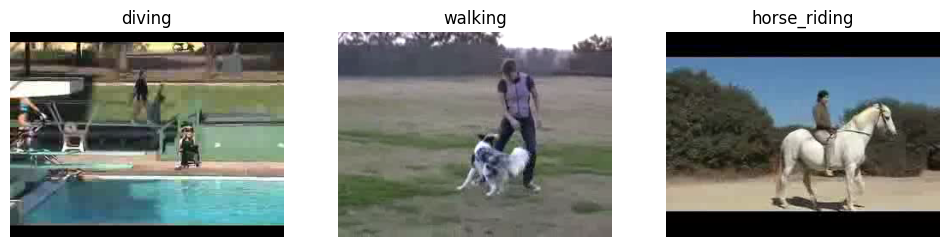

In [17]:
plt.figure(figsize=(12, 6))

for counter, class_name in enumerate(classes_list, 1):
    class_folder = class_folder_paths[class_name]
    video_files = []
    for root, dirs, files in os.walk(class_folder):
        for file in files:
            if file.lower().endswith((".avi", ".mp4", ".mpg", ".mpeg", ".mov")):
                video_files.append(os.path.join(root, file))

    selected_video_path = random.choice(video_files)
    video_reader = cv2.VideoCapture(selected_video_path)
    success, bgr_frame = video_reader.read()
    video_reader.release()

    if success:
        rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(classes_list), counter)
        plt.imshow(rgb_frame)
        plt.title(class_name)
        plt.axis("off")

plt.show()


In [18]:
def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list


In [19]:
def create_dataset():
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f"Extracting Data of Class: {class_name}")
        temp_features = []
        class_folder = class_folder_paths[class_name]

        video_files = []
        for root, dirs, files in os.walk(class_folder):
            for file_name in files:
                if file_name.lower().endswith((".avi", ".mp4", ".mpg", ".mpeg", ".mov")):
                    video_files.append(os.path.join(root, file_name))

        for video_file_path in video_files:
            frames = frames_extraction(video_file_path)
            temp_features.extend(frames)

        sample_count = min(max_images_per_class, len(temp_features))
        selected_features = random.sample(temp_features, sample_count)

        features.extend(selected_features)
        labels.extend([class_index] * sample_count)

        print(f"Total extracted frames: {len(temp_features)}")
        print(f"Selected frames used: {sample_count}")

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels

features, labels = create_dataset()

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)


Extracting Data of Class: diving
Total extracted frames: 834
Selected frames used: 834
Extracting Data of Class: walking
Total extracted frames: 837
Selected frames used: 837
Extracting Data of Class: horse_riding
Total extracted frames: 1175
Selected frames used: 1175
Features shape: (2846, 64, 64, 3)
Labels shape: (2846,)


In [20]:
one_hot_encoded_labels = to_categorical(labels, num_classes=model_output_size)
print("One-hot labels shape:", one_hot_encoded_labels.shape)


One-hot labels shape: (2846, 3)


In [21]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant,
    stratify=labels
)

print("Training features shape:", features_train.shape)
print("Testing features shape:", features_test.shape)
print("Training labels shape:", labels_train.shape)
print("Testing labels shape:", labels_test.shape)


Training features shape: (2276, 64, 64, 3)
Testing features shape: (570, 64, 64, 3)
Training labels shape: (2276, 3)
Testing labels shape: (570, 3)


In [22]:
def create_model():
    model = Sequential()

    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu", input_shape=(image_height, image_width, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(model_output_size, activation="softmax"))

    model.summary()
    return model

model = create_model()
print("Model Created Successfully!")


/opt/anaconda3/envs/cv_lab/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


In [24]:
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    restore_best_weights=True
)

model.compile(
    loss="categorical_crossentropy",
    optimizer="Adam",
    metrics=["accuracy"]
)

model_training_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=10,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)


Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.9198 - loss: 0.2270 - val_accuracy: 0.4145 - val_loss: 1.1626
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9786 - loss: 0.0694 - val_accuracy: 0.9145 - val_loss: 0.2921
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9890 - loss: 0.0364 - val_accuracy: 0.9912 - val_loss: 0.0253
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9813 - loss: 0.0453 - val_accuracy: 0.4846 - val_loss: 3.9135
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9962 - loss: 0.0174 - val_accuracy: 0.9912 - val_loss: 0.0253
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9984 - loss: 0.0104 - val_accuracy: 0.9561 - val_loss: 0.1371
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9819 - loss: 0.0507 - val_accuracy: 0.8224 - val_loss: 0.6949
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9951 - loss: 0.0203 - 

In [25]:
model_evaluation_history = model.evaluate(features_test, labels_test)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

print("Test Loss:", model_evaluation_loss)
print("Test Accuracy:", model_evaluation_accuracy)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 0.0021
Test Loss: 0.0021224464289844036
Test Accuracy: 1.0


In [26]:
student_name = "Nora Alsunaid"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

Model saved as Nora Alsunaid_ucf11_model.h5


In [31]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
    
    # check if metrics exist
    if metric_name_1 not in model_training_history.history:
        print(f"{metric_name_1} not found in history!")
        print("Available keys:", model_training_history.history.keys())
        return

    if metric_name_2 not in model_training_history.history:
        print(f"{metric_name_2} not found in history!")
        print("Available keys:", model_training_history.history.keys())
        return

    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    epochs = range(1, len(metric_value_1) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metric_value_1, marker='o', label=metric_name_1)
    plt.plot(epochs, metric_value_2, marker='o', label=metric_name_2)

    plt.title(plot_name)
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    plt.show()

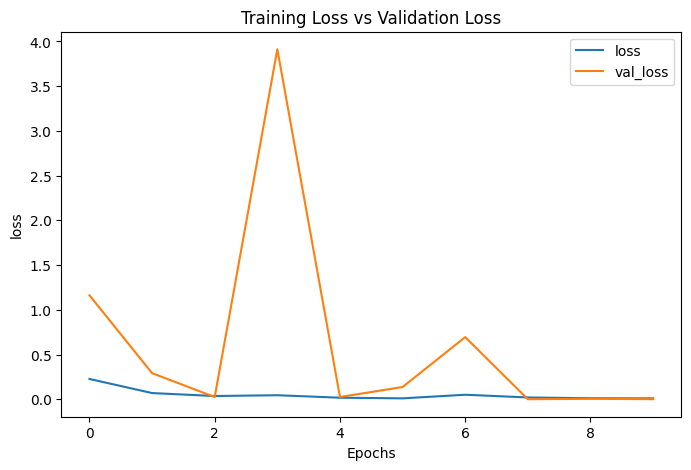

In [28]:
plot_metric("loss", "val_loss", "Training Loss vs Validation Loss")


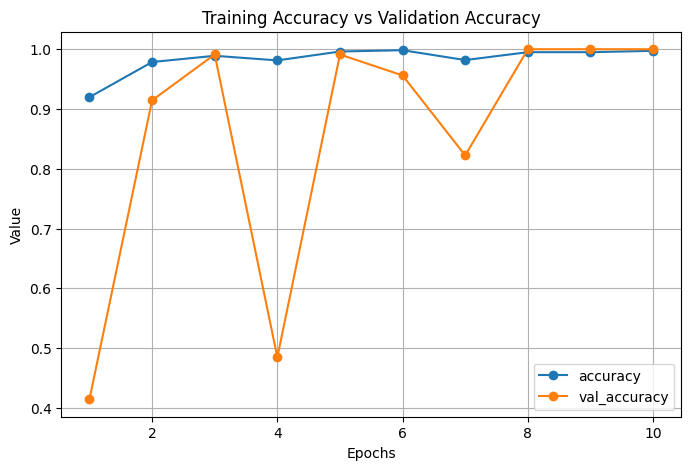

In [32]:
plot_metric("accuracy", "val_accuracy", "Training Accuracy vs Validation Accuracy")


In [34]:
def predict_on_live_video(video_file_path, output_file_path, window_size=25):
    predicted_labels_probabilities_deque = deque(maxlen=window_size)

    video_reader = cv2.VideoCapture(video_file_path)

    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_reader.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 24

    video_writer = cv2.VideoWriter(
        output_file_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (original_video_width, original_video_height)
    )

    while True:
        status, frame = video_reader.read()

        if not status:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0),
            verbose=0
        )[0]

        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        if len(predicted_labels_probabilities_deque) == window_size:
            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)

            predicted_label = np.argmax(predicted_labels_probabilities_averaged)
            predicted_class_name = classes_list[predicted_label]
            confidence = predicted_labels_probabilities_averaged[predicted_label]

            text = f"{predicted_class_name}: {confidence:.2f}"
            cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        video_writer.write(frame)

    video_reader.release()
    video_writer.release()
    print("Saved output video:", output_file_path)


In [35]:
predict_on_live_video("Diving.mov", "output_diving.mp4")
predict_on_live_video("walking.mov", "output_walking.mp4")
predict_on_live_video("Horse_Riding.mov", "output_horse_riding.mp4")

Saved output video: output_diving.mp4
Saved output video: output_walking.mp4
Saved output video: output_horse_riding.mp4


In [36]:
def make_average_predictions(video_file_path, predictions_frames_count=50):
    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype=float)

    video_reader = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count == 0:
        video_reader.release()
        print("Could not read video:", video_file_path)
        return

    skip_frames_window = max(video_frames_count // predictions_frames_count, 1)

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()

        if not success:
            continue

        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0),
            verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    print("Final video prediction results:")
    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:
        predicted_class_name = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS NAME: {predicted_class_name:<15} AVERAGED PROBABILITY: {predicted_probability:.2f}")

    video_reader.release()


In [37]:
make_average_predictions("Diving.mov")
make_average_predictions("walking.mov")
make_average_predictions("Horse_Riding.mov")

Final video prediction results:
CLASS NAME: diving          AVERAGED PROBABILITY: 0.80
CLASS NAME: walking         AVERAGED PROBABILITY: 0.00
CLASS NAME: horse_riding    AVERAGED PROBABILITY: 0.00
Final video prediction results:
CLASS NAME: walking         AVERAGED PROBABILITY: 1.00
CLASS NAME: diving          AVERAGED PROBABILITY: 0.00
CLASS NAME: horse_riding    AVERAGED PROBABILITY: 0.00
Final video prediction results:
CLASS NAME: horse_riding    AVERAGED PROBABILITY: 0.27
CLASS NAME: diving          AVERAGED PROBABILITY: 0.24
CLASS NAME: walking         AVERAGED PROBABILITY: 0.16


links to videos:https://youtube.com/shorts/sQi8DuxqAFU?si=NxZFqFysyaW2Yv3M, https://www.youtube.com/shorts/QQMA6TIWZWg, https://www.youtube.com/shorts/9UYmnpa1s80?feature=share